In [17]:
# ==========================================
# CELL 1 — LOAD SPOT + IV + SMILE FEATURES (SAME AS NOTEBOOK 5)
# ==========================================
# This notebook asks a DIFFERENT question than notebook 5. Instead of
# "what will 30-day realized vol be exactly", we ask a simpler, more
# actionable question: "will volatility jump into a HIGH regime in the next
# 30 days, yes or no". Classification is often easier to get right than
# precise regression, and the answer is directly useful - e.g. "should I
# hedge this week" doesn't need an exact vol number, just a yes/no signal.

import glob
import os
import numpy as np
import pandas as pd

folder = r"C:\Users\ASUS\Desktop\volPredict"

print("=== LOADING FUTURES FILES FOR DAILY SPOT SERIES ===")
fut_files = sorted(glob.glob(os.path.join(folder, "FUTIDX_NIFTY_*.csv")))
fut_list = []
for f in fut_files:
    d = pd.read_csv(f)
    d.columns = d.columns.str.strip()
    fut_list.append(d)
fut = pd.concat(fut_list, ignore_index=True)
fut["Date"] = pd.to_datetime(fut["Date"].str.strip(), format="%d-%b-%Y")
fut["Underlying Value"] = pd.to_numeric(fut["Underlying Value"].astype(str).str.strip(), errors="coerce")
spot = fut.dropna(subset=["Underlying Value"]).groupby("Date")["Underlying Value"].first().reset_index()
spot = spot.rename(columns={"Underlying Value": "Spot"}).sort_values("Date").reset_index(drop=True)
print(f"✓ Built daily spot series: {len(spot):,} trading days")

TRADING_DAYS_PER_YEAR = 252
spot["LogReturn"] = np.log(spot["Spot"] / spot["Spot"].shift(1))

def forward_realized_vol(log_returns, window):
    n = len(log_returns)
    result = np.full(n, np.nan)
    for i in range(n - window):
        result[i] = np.std(log_returns[i + 1 : i + 1 + window], ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
    return result

spot["RV_30D_fwd"] = forward_realized_vol(spot["LogReturn"].values, 30)
spot["RV_14D_trailing"] = spot["LogReturn"].rolling(14).std() * np.sqrt(TRADING_DAYS_PER_YEAR)
spot["RV_30D_trailing"] = spot["LogReturn"].rolling(30).std() * np.sqrt(TRADING_DAYS_PER_YEAR)

iv_feat = pd.read_csv(os.path.join(folder, "daily_volatility_features.csv"), parse_dates=["Date"])
df = pd.merge(iv_feat, spot, on="Date", how="inner")
df["VRP_30D"] = df["ATM_IV_30D"] - df["RV_30D_trailing"]
df["VRP_14D"] = df["ATM_IV_14D"] - df["RV_14D_trailing"]
df["Term_Slope"] = df["ATM_IV_30D"] - df["ATM_IV_14D"]

smile_feat_path = os.path.join(folder, "smile_features.csv")
if os.path.exists(smile_feat_path):
    smile_feat = pd.read_csv(smile_feat_path, parse_dates=["Date"])
    smile_cols = ["Date", "Smile_Level_30D", "Smile_Skew_30D", "Smile_Curv_30D",
                  "Smile_Level_14D", "Smile_Skew_14D", "Smile_Curv_14D",
                  "Skew_Term_Slope", "Curv_Term_Slope"]
    df = pd.merge(df, smile_feat[smile_cols], on="Date", how="left")
    HAVE_SMILE_FEATURES = df["Smile_Level_30D"].notna().sum() > 0
else:
    HAVE_SMILE_FEATURES = False

df = df.sort_values("Date").reset_index(drop=True)
print(f"✓ Merged table ready: {len(df):,} rows. Smile features available: {HAVE_SMILE_FEATURES}")

=== LOADING FUTURES FILES FOR DAILY SPOT SERIES ===
✓ Built daily spot series: 651 trading days
✓ Merged table ready: 651 rows. Smile features available: True


In [18]:
# ==========================================
# CELL 2 — DEFINE THE REGIME / SPIKE LABEL
# ==========================================
# "Spike" = the 75th percentile of trailing 30-day realized vol, computed
# over the WHOLE history. Using a fixed historical threshold (rather than a
# rolling one) keeps the label simple and interpretable: it means "vol enters
# the top quartile of what NIFTY has historically done", a meaningfully high
# regime, not just any small uptick.
#
# Label = 1 if RV_30D_fwd (the FUTURE 30-day realized vol) crosses this
# threshold. Label = 0 otherwise. This uses only past history for the
# threshold itself, so there's no lookahead bias in picking the cutoff.

print("=== DEFINING SPIKE / REGIME LABEL ===")

SPIKE_THRESHOLD = df["RV_30D_trailing"].quantile(0.75)
print(f"Spike threshold (75th percentile of historical trailing RV): {SPIKE_THRESHOLD:.4f}")

df["Spike_Label"] = (df["RV_30D_fwd"] > SPIKE_THRESHOLD).astype("Int64")

label_counts = df["Spike_Label"].value_counts(dropna=True)
print()
print("Label distribution (before dropping NaN rows):")
print(label_counts)
print(f"Spike rate: {label_counts.get(1, 0) / label_counts.sum() * 100:.1f}%")

=== DEFINING SPIKE / REGIME LABEL ===
Spike threshold (75th percentile of historical trailing RV): 0.2064

Label distribution (before dropping NaN rows):
Spike_Label
0    496
1    155
Name: count, dtype: Int64
Spike rate: 23.8%


In [19]:
# ==========================================
# CELL 3 — FEATURE ENGINEERING
# ==========================================
print("=== BUILDING FEATURE SET ===")

FEATURE_COLS = [
    "ATM_IV_30D", "PUT_IV_30D", "CALL_IV_30D", "SKEW_30D",
    "ATM_IV_14D", "PUT_IV_14D", "CALL_IV_14D", "SKEW_14D",
    "RV_14D_trailing", "RV_30D_trailing",
    "VRP_30D", "VRP_14D", "Term_Slope",
]

for col in ["ATM_IV_30D", "SKEW_30D", "Term_Slope"]:
    df[f"{col}_chg1d"] = df[col].diff(1)
    FEATURE_COLS.append(f"{col}_chg1d")

df["ATM_IV_30D_ma5"] = df["ATM_IV_30D"].rolling(5).mean()
FEATURE_COLS.append("ATM_IV_30D_ma5")

if HAVE_SMILE_FEATURES:
    SMILE_FEATURE_COLS = [
        "Smile_Level_30D", "Smile_Skew_30D", "Smile_Curv_30D",
        "Smile_Level_14D", "Smile_Skew_14D", "Smile_Curv_14D",
        "Skew_Term_Slope", "Curv_Term_Slope",
    ]
    FEATURE_COLS += SMILE_FEATURE_COLS

TARGET_COL = "Spike_Label"

model_df = df[["Date"] + FEATURE_COLS + [TARGET_COL]].dropna().reset_index(drop=True)
model_df[TARGET_COL] = model_df[TARGET_COL].astype(int)

print(f"✓ Final modeling table: {len(model_df):,} rows, {len(FEATURE_COLS)} features")
print(f"  Spike rate in usable rows: {model_df[TARGET_COL].mean()*100:.1f}%")

=== BUILDING FEATURE SET ===
✓ Final modeling table: 621 rows, 25 features
  Spike rate in usable rows: 20.1%


In [20]:
# ==========================================
# CELL 4 — NOTE ON EVALUATION APPROACH
# ==========================================
# We skip a single fixed 80/20 split here. NIFTY had an unusually calm
# stretch from late 2024 into mid 2025 - if that happens to land entirely in
# a fixed test set, there are zero spike examples to evaluate against, and
# precision/recall become meaningless. Time-series cross-validation (next
# cell) avoids this by testing across several different time windows.

print("Skipping single fixed split - see time-series CV in the next cell.")

Skipping single fixed split - see time-series CV in the next cell.


In [21]:
# ==========================================
# CELL 4b — TIME-SERIES CROSS-VALIDATION (HONEST EVALUATION)
# ==========================================
# Instead of one fixed split, we use expanding-window cross-validation:
# fold 1 trains on the earliest chunk and tests on the next chunk, fold 2
# trains on everything so far and tests on the next chunk, and so on. Every
# fold's test period is still strictly AFTER its training period (no
# lookahead), but across all folds combined we see performance across both
# calm AND volatile periods, not just whichever regime the last 20% happens
# to be in.

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
)

print("=== TIME-SERIES CROSS-VALIDATION ===")

def report_clf(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    line = f"{name:<28} Acc={acc:.3f}  Prec={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}"
    if y_proba is not None and len(set(y_true)) > 1:
        auc = roc_auc_score(y_true, y_proba)
        line += f"  AUC={auc:.3f}"
    print(line)
    return acc, prec, rec, f1

tscv = TimeSeriesSplit(n_splits=5)
X_all, y_all = model_df[FEATURE_COLS], model_df[TARGET_COL]

cv_results = []
all_y_true, all_y_pred, all_y_proba = [], [], []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_all), 1):
    X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
    y_tr, y_te = y_all.iloc[tr_idx], y_all.iloc[te_idx]

    if y_te.sum() == 0:
        print(f"Fold {fold}: skipped (no positive examples in this test window)")
        continue

    model = GradientBoostingClassifier(
        n_estimators=100, max_depth=2, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=10, random_state=42,
    )
    fold_weight = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    fold_sample_weights = np.where(y_tr == 1, fold_weight, 1.0)
    model.fit(X_tr, y_tr, sample_weight=fold_sample_weights)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    acc, prec, rec, f1 = report_clf(f"Fold {fold}", y_te, pred, proba)
    cv_results.append({"fold": fold, "acc": acc, "prec": prec, "recall": rec, "f1": f1, "n_test": len(y_te), "n_spikes": y_te.sum()})
    all_y_true.extend(y_te.tolist())
    all_y_pred.extend(pred.tolist())
    all_y_proba.extend(proba.tolist())

print()
cv_df = pd.DataFrame(cv_results)
print(cv_df)
print()
print("--- Average across valid folds ---")
print(cv_df[["acc", "prec", "recall", "f1"]].mean())
print()
print("--- Combined confusion matrix (all folds pooled) ---")
cm_all = confusion_matrix(all_y_true, all_y_pred)
print(pd.DataFrame(cm_all, index=["Actual: No Spike", "Actual: Spike"], columns=["Pred: No Spike", "Pred: Spike"]))

=== TIME-SERIES CROSS-VALIDATION ===
Fold 1: skipped (no positive examples in this test window)
Fold 2: skipped (no positive examples in this test window)
Fold 3                       Acc=0.631  Prec=0.000  Recall=0.000  F1=0.000  AUC=0.501
Fold 4: skipped (no positive examples in this test window)
Fold 5: skipped (no positive examples in this test window)

   fold       acc  prec  recall   f1  n_test  n_spikes
0     3  0.631068   0.0     0.0  0.0     103        30

--- Average across valid folds ---
acc       0.631068
prec      0.000000
recall    0.000000
f1        0.000000
dtype: float64

--- Combined confusion matrix (all folds pooled) ---
                  Pred: No Spike  Pred: Spike
Actual: No Spike              65            8
Actual: Spike                 30            0


In [22]:
# ==========================================
# CELL 5 — BASELINES ON A CV FOLD THAT ACTUALLY CONTAINS SPIKES
# ==========================================
# We reuse whichever cross-validation fold above had spike examples in its
# test window (not necessarily the LAST fold - NIFTY vol has been unusually
# calm recently, so the most recent fold may have zero spikes to evaluate
# against). This gives a meaningful baseline/model comparison.

from sklearn.linear_model import LogisticRegression

print("=== BASELINES ON A CV FOLD WITH SPIKE EXAMPLES ===")

folds_with_spikes = [r["fold"] for r in cv_results if r["n_spikes"] > 0]
if not folds_with_spikes:
    raise ValueError("No CV fold contained spike examples - try a lower SPIKE_THRESHOLD percentile.")
chosen_fold = folds_with_spikes[-1]  # most recent fold that still has spikes
tr_idx, te_idx = list(tscv.split(X_all))[chosen_fold - 1]

X_train, X_test = X_all.iloc[tr_idx], X_all.iloc[te_idx]
y_train, y_test = y_all.iloc[tr_idx], y_all.iloc[te_idx]
test_df = model_df.iloc[te_idx].copy()

print(f"Using fold {chosen_fold}, test window: {test_df['Date'].min().date()} to {test_df['Date'].max().date()}")
print(f"  Test spike rate: {y_test.mean()*100:.1f}%")
print()

majority_pred = np.zeros(len(y_test), dtype=int)
report_clf("Always predict 'no spike'", y_test, majority_pred)

persistence_pred = (test_df["RV_30D_trailing"] > SPIKE_THRESHOLD).astype(int).values
report_clf("Naive (currently high = spike)", y_test, persistence_pred)

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:, 1]
report_clf("Logistic Regression", y_test, log_pred, log_proba)

=== BASELINES ON A CV FOLD WITH SPIKE EXAMPLES ===
Using fold 3, test window: 2023-12-14 to 2024-06-20
  Test spike rate: 29.1%

Always predict 'no spike'    Acc=0.709  Prec=0.000  Recall=0.000  F1=0.000
Naive (currently high = spike) Acc=0.631  Prec=0.000  Recall=0.000  F1=0.000
Logistic Regression          Acc=0.621  Prec=0.154  Recall=0.067  F1=0.093  AUC=0.505


(0.6213592233009708,
 0.15384615384615385,
 0.06666666666666667,
 0.09302325581395349)

In [23]:
# ==========================================
# CELL 6 — GRADIENT BOOSTED CLASSIFIER (main model)
# ==========================================
# The spike class is a minority (~20% of days), so we weight spike examples
# more heavily during training (class_weight isn't a native GradientBoosting
# parameter, so we pass explicit sample_weight instead). Without this, the
# model can get high accuracy just by predicting "no spike" almost always -
# exactly the failure mode a majority-class baseline would also achieve.

print("=== TRAINING GRADIENT BOOSTED CLASSIFIER (CLASS-WEIGHTED) ===")

spike_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
sample_weights = np.where(y_train == 1, spike_weight, 1.0)
print(f"Spike class weight: {spike_weight:.2f}x (spikes are {(y_train==1).mean()*100:.1f}% of training data)")

gbc = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42,
)
gbc.fit(X_train, y_train, sample_weight=sample_weights)
gbc_pred = gbc.predict(X_test)
gbc_proba = gbc.predict_proba(X_test)[:, 1]

report_clf("Gradient Boosting Classifier", y_test, gbc_pred, gbc_proba)
print()
print("NOTE: even with class weighting, the model may still default toward")
print("the majority ('no spike') class on some folds if the training window")
print("doesn't contain a similar regime transition to the test window. This")
print("is a genuine finding about how hard the task is, not a bug - see the")
print("pooled cross-validation results in Cell 4b for the full picture across")
print("multiple time windows.")

print()
print("--- Confusion matrix on this fold (rows=actual, cols=predicted) ---")
cm = confusion_matrix(y_test, gbc_pred)
print(pd.DataFrame(cm, index=["Actual: No Spike", "Actual: Spike"], columns=["Pred: No Spike", "Pred: Spike"]))

print()
print("--- Feature importance ---")
importance = pd.Series(gbc.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(importance.head(10))

=== TRAINING GRADIENT BOOSTED CLASSIFIER (CLASS-WEIGHTED) ===
Spike class weight: 2.28x (spikes are 30.4% of training data)


Gradient Boosting Classifier Acc=0.631  Prec=0.000  Recall=0.000  F1=0.000  AUC=0.501

NOTE: even with class weighting, the model may still default toward
the majority ('no spike') class on some folds if the training window
doesn't contain a similar regime transition to the test window. This
is a genuine finding about how hard the task is, not a bug - see the
pooled cross-validation results in Cell 4b for the full picture across
multiple time windows.

--- Confusion matrix on this fold (rows=actual, cols=predicted) ---
                  Pred: No Spike  Pred: Spike
Actual: No Spike              65            8
Actual: Spike                 30            0

--- Feature importance ---
RV_30D_trailing    0.737471
RV_14D_trailing    0.116812
VRP_14D            0.062214
VRP_30D            0.024903
Term_Slope         0.022154
ATM_IV_30D_ma5     0.012840
ATM_IV_30D         0.003800
SKEW_30D           0.003100
SKEW_14D           0.002921
Smile_Skew_14D     0.002904
dtype: float64


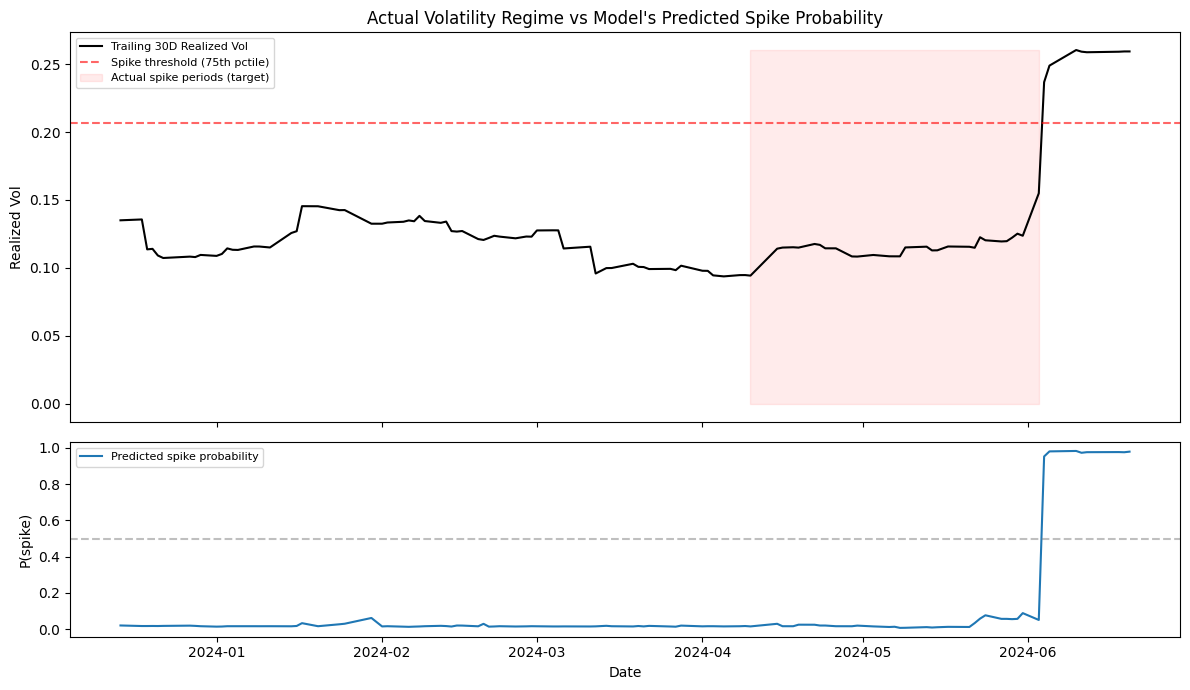

✓ Predicted probability (bottom) should rise BEFORE or DURING the shaded
  red regions (top) if the model has real predictive value.


In [24]:
# ==========================================
# CELL 7 — VISUALIZE: PREDICTED SPIKE PROBABILITY VS ACTUAL REGIME
# ==========================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, height_ratios=[2, 1])

axes[0].plot(test_df["Date"], test_df["RV_30D_trailing"], color="black", label="Trailing 30D Realized Vol")
axes[0].axhline(SPIKE_THRESHOLD, color="red", linestyle="--", alpha=0.6, label="Spike threshold (75th pctile)")
axes[0].fill_between(test_df["Date"], 0, test_df["RV_30D_trailing"].max(),
                      where=(test_df[TARGET_COL] == 1), color="red", alpha=0.08, label="Actual spike periods (target)")
axes[0].set_ylabel("Realized Vol")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].set_title("Actual Volatility Regime vs Model's Predicted Spike Probability")

axes[1].plot(test_df["Date"], gbc_proba, color="tab:blue", label="Predicted spike probability")
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[1].set_ylabel("P(spike)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("regime_classification_test.png", dpi=100)
plt.show()

print("✓ Predicted probability (bottom) should rise BEFORE or DURING the shaded")
print("  red regions (top) if the model has real predictive value.")